# Correct Folding in Deformation Fields

Test the iterative SLSQP correction on 2D slices extracted from a 3D
displacement field.  Two modes:

1. **Synthetic test case** (default) — generates a small 3D warp volume
   with deliberate folding in selected slices.  No external data needed.
2. **ANTs / NIfTI warp** — load a real `.nii.gz` displacement field from
   ANTs registration and correct slices with negative Jacobians.

**Pipeline per slice:**
1. Extract one axial slice → convert to `(3, 1, H, W)` with `[dz=0, dy, dx]`
2. Compute Jacobian determinant, report negative-Jdet pixels
3. Run `iterative_parallel` to correct folding
4. Visualise before/after grids
5. (Optional) Write corrected slices back and save NIfTI

## Imports

In [1]:
import os
import time

import numpy as np

from modules.dvfopt import jacobian_det2D, iterative_parallel, scale_dvf
from modules.dvfviz import (
    plot_grid_before_after,
    plot_checkerboard_before_after,
    plot_neg_jdet_neighborhoods,
)

## Configuration

Set `USE_SYNTHETIC = True` to run with a generated test volume (no files
needed).  Set it to `False` and fill in `WARP_PATH` to load a real NIfTI
displacement field.

In [2]:
# --- Mode: synthetic test case or real NIfTI ---
USE_SYNTHETIC = True

# --- Path to ANTs warp (only used when USE_SYNTHETIC = False) ---
WARP_PATH = "path/to/ants_warp.nii.gz"

# --- Output directory for corrected results ---
OUTPUT_DIR = "output/ants_corrections"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Jacobian determinant threshold ---
JDET_THRESHOLD = 0.01

# --- Slices to correct (axial slice indices) ---
# Set to None to auto-detect all slices with negative Jacobians
SLICE_INDICES = None   # e.g. [90, 200, 350] or None for auto-detect

# --- Downscale factor (1.0 = full resolution, 0.2 = 20%) ---
SCALE_FACTOR = 1.0

## Load or generate the 3D warp

* **Synthetic mode** — creates a `(30, 30, 10)` volume.  Most slices have
  smooth displacements (positive Jacobians).  Slices 3 and 6 have
  crossing/opposing displacement patterns that produce negative Jacobians,
  mimicking the kind of folding seen in real registration warps.
* **NIfTI mode** — loads an ANTs displacement field and converts from
  ITK `(x,y,z)` to internal `[dz, dy, dx]`.

In [3]:
nii = None  # will be set only in NIfTI mode (needed for saving)
warp_data = None

if USE_SYNTHETIC:
    # --- Generate a synthetic 3D warp with folding in specific slices ---
    H, W, D = 30, 30, 10
    rng = np.random.default_rng(42)

    # Start with a smooth background displacement (small random field)
    warp_zyx = np.zeros((3, H, W, D), dtype=np.float64)
    # Gentle smooth displacement on all slices
    for z in range(D):
        warp_zyx[1, :, :, z] = 0.3 * np.sin(2 * np.pi * np.arange(H)[:, None] / H)
        warp_zyx[2, :, :, z] = 0.3 * np.cos(2 * np.pi * np.arange(W)[None, :] / W)

    # Slice 3: crossing displacement — two groups pulling in opposite x-directions
    yy, xx = np.mgrid[0:H, 0:W].astype(float)
    cy, cx = H // 2, W // 2
    r = np.sqrt((yy - cy)**2 + (xx - cx)**2)
    mask = r < 8
    warp_zyx[2, :, :, 3] += mask * np.where(yy < cy, 4.0, -4.0)  # dx: opposing
    warp_zyx[1, :, :, 3] += mask * np.where(xx < cx, 2.0, -2.0)  # dy: crossing

    # Slice 6: vortex-like pattern that creates folding
    angle = np.arctan2(yy - cy, xx - cx)
    strength = np.exp(-r**2 / (2 * 6**2)) * 5.0
    warp_zyx[1, :, :, 6] += strength * np.cos(angle)  # dy
    warp_zyx[2, :, :, 6] -= strength * np.sin(angle)  # dx (vortex)

    print(f"Generated synthetic warp: (3, {H}, {W}, {D})")
    print(f"  Slices with injected folding: 3, 6")

else:
    # --- Load real NIfTI displacement field ---
    import nibabel as nib
    nii = nib.load(WARP_PATH)
    warp_data = nii.get_fdata()
    print(f"Loaded: {WARP_PATH}")
    print(f"  NIfTI shape : {nii.shape}")
    print(f"  Data shape  : {warp_data.shape}")
    print(f"  Voxel size  : {nii.header.get_zooms()}")

    # Handle 5D ANTs format: (X, Y, Z, 1, 3) → (X, Y, Z, 3)
    if warp_data.ndim == 5 and warp_data.shape[3] == 1:
        warp_data = warp_data[:, :, :, 0, :]
        print(f"  Squeezed 5D → 4D: {warp_data.shape}")

    assert warp_data.ndim == 4 and warp_data.shape[-1] == 3, (
        f"Expected (X, Y, Z, 3), got {warp_data.shape}"
    )

    # ANTs/ITK vectors are (x, y, z) → reorder to (z, y, x)
    warp_zyx = np.stack([
        warp_data[..., 2],  # dz
        warp_data[..., 1],  # dy
        warp_data[..., 0],  # dx
    ], axis=0)

print(f"\nInternal shape (3, X, Y, Z): {warp_zyx.shape}")
print(f"Displacement range  dz: [{warp_zyx[0].min():.3f}, {warp_zyx[0].max():.3f}]")
print(f"                    dy: [{warp_zyx[1].min():.3f}, {warp_zyx[1].max():.3f}]")
print(f"                    dx: [{warp_zyx[2].min():.3f}, {warp_zyx[2].max():.3f}]")

Generated synthetic warp: (3, 30, 30, 10)
  Slices with injected folding: 3, 6

Internal shape (3, X, Y, Z): (3, 30, 30, 10)
Displacement range  dz: [0.000, 0.000]
                    dy: [-4.931, 5.000]
                    dx: [-5.231, 4.631]


## Identify slices with negative Jacobians

In [4]:
n_slices = warp_zyx.shape[3]  # Z dimension (axial slices)

# Survey every slice for negative Jacobians
slice_neg_counts = {}
print(f"Scanning {n_slices} axial slices for negative Jacobians...")

for z in range(n_slices):
    # Extract 2D slice: (3, X, Y) → (2, H, W) with [dy, dx]
    dy_slice = warp_zyx[1, :, :, z]
    dx_slice = warp_zyx[2, :, :, z]
    phi_2d = np.stack([dy_slice, dx_slice])  # (2, H, W)
    jac = jacobian_det2D(phi_2d)
    n_neg = int((jac <= 0).sum())
    if n_neg > 0:
        slice_neg_counts[z] = n_neg

print(f"\nSlices with negative Jacobians: {len(slice_neg_counts)} / {n_slices}")
if slice_neg_counts:
    # Show top 20 worst slices
    sorted_slices = sorted(slice_neg_counts.items(), key=lambda x: -x[1])
    print(f"\n{'Slice':>6s}  {'Neg Jdet':>10s}")
    print("-" * 20)
    for z, count in sorted_slices[:20]:
        print(f"{z:>6d}  {count:>10d}")
    if len(sorted_slices) > 20:
        print(f"  ... and {len(sorted_slices) - 20} more slices")

Scanning 10 axial slices for negative Jacobians...

Slices with negative Jacobians: 1 / 10

 Slice    Neg Jdet
--------------------
     3          39


## Helper: extract a 2D deformation from an axial slice

In [5]:
def extract_slice(warp_zyx, slice_idx, scale_factor=1.0):
    """Extract an axial slice from the 3D warp as a (3, 1, H, W) deformation.

    Parameters
    ----------
    warp_zyx : ndarray, shape (3, X, Y, Z)
        Full 3D warp in [dz, dy, dx] convention.
    slice_idx : int
        Axial slice index along the Z axis.
    scale_factor : float
        If < 1.0, downscale the slice for faster correction.

    Returns
    -------
    deformation : ndarray, shape (3, 1, H, W)
        2D deformation field with dz=0.
    """
    dz_slice = np.zeros_like(warp_zyx[0, :, :, slice_idx])
    dy_slice = warp_zyx[1, :, :, slice_idx].copy()
    dx_slice = warp_zyx[2, :, :, slice_idx].copy()

    H, W = dy_slice.shape
    deformation = np.stack([
        dz_slice[np.newaxis, :, :],
        dy_slice[np.newaxis, :, :],
        dx_slice[np.newaxis, :, :],
    ])  # (3, 1, H, W)

    if scale_factor < 1.0:
        new_H = max(2, int(H * scale_factor))
        new_W = max(2, int(W * scale_factor))
        deformation = scale_dvf(deformation, (new_H, new_W))
        print(f"  Downscaled {H}x{W} → {new_H}x{new_W}")

    return deformation

## Helper: run correction and visualise

In [6]:
def correct_and_show(key, deformation, **kwargs):
    """Run iterative_parallel on a 2D slice deformation, save and plot."""
    save_dir = f"{OUTPUT_DIR}/{key}"

    H, W = deformation.shape[-2:]
    phi_init = np.stack([deformation[1, 0], deformation[2, 0]])
    jac_init = jacobian_det2D(phi_init)
    n_neg = int((jac_init <= 0).sum())
    n_below = int((jac_init <= JDET_THRESHOLD).sum())
    min_jdet = float(jac_init.min())

    print(f"\n{'='*70}")
    print(f"  {key}  |  {H}x{W}  |  neg Jdet: {n_neg}  "
          f"|  below threshold ({JDET_THRESHOLD}): {n_below}  "
          f"|  min Jdet: {min_jdet:.4f}")
    print(f"{'='*70}")

    if n_neg == 0:
        print("  No negative Jacobians — skipping correction.")
        return None

    t0 = time.perf_counter()
    phi = iterative_parallel(
        deformation.copy(), save_path=save_dir, verbose=1,
        threshold=JDET_THRESHOLD, **kwargs
    )
    elapsed = time.perf_counter() - t0

    jac_final = jacobian_det2D(phi)
    n_neg_final = int((jac_final <= 0).sum())
    n_below_final = int((jac_final <= JDET_THRESHOLD).sum())
    min_jdet_final = float(jac_final.min())
    l2 = float(np.sqrt(np.sum((phi - phi_init) ** 2)))

    print(f"  Time: {elapsed:.2f}s  |  neg Jdet: {n_neg} → {n_neg_final}  "
          f"|  below threshold: {n_below} → {n_below_final}  "
          f"|  min Jdet: {min_jdet:.4f} → {min_jdet_final:.4f}  |  L2: {l2:.4f}")

    plot_grid_before_after(deformation, phi, title=key)
    plot_checkerboard_before_after(deformation, phi, title=key)
    plot_neg_jdet_neighborhoods(deformation, phi, title=key)
    return phi

## Select slices to correct

In [7]:
if SLICE_INDICES is None:
    # Auto: pick all slices with negative Jacobians
    slices_to_correct = sorted(slice_neg_counts.keys())
    print(f"Auto-selected {len(slices_to_correct)} slices with negative Jacobians")
else:
    slices_to_correct = SLICE_INDICES
    print(f"User-selected slices: {slices_to_correct}")

print(f"Scale factor: {SCALE_FACTOR}")

Auto-selected 1 slices with negative Jacobians
Scale factor: 1.0


## Run corrections


  slice_0003  |  30x30  |  neg Jdet: 39  |  below threshold (0.01): 46  |  min Jdet: -7.0745
[init] Grid 30x30  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 39  |  min Jdet: -7.074533
[iter    1]  serial  fix ( 15, 14)  neg_pixels=46
         -> neg_jdet     0  min_jdet +0.010000  L2 10.1383  win 21  sub-iters 7
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP — hybrid parallel)
------------------------------------------------------------
  Grid size        : 30 x 30
  Iterations       : 1  (serial=1, parallel=0)
  Neg-Jdet     39 ->     0
  Min Jdet  -7.074533 -> +0.010000
  L2 error         : 10.138302
  Time             : 14.21s
  Time: 14.21s  |  neg Jdet: 39 → 0  |  below threshold: 46 → 29  |  min Jdet: -7.0745 → 0.0100  |  L2: 10.1383


c:\Users\Andy\Documents\GitHub\UCI-iGravi\deformation-field-processing\modules\dvfviz.py:842: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.87, 1])


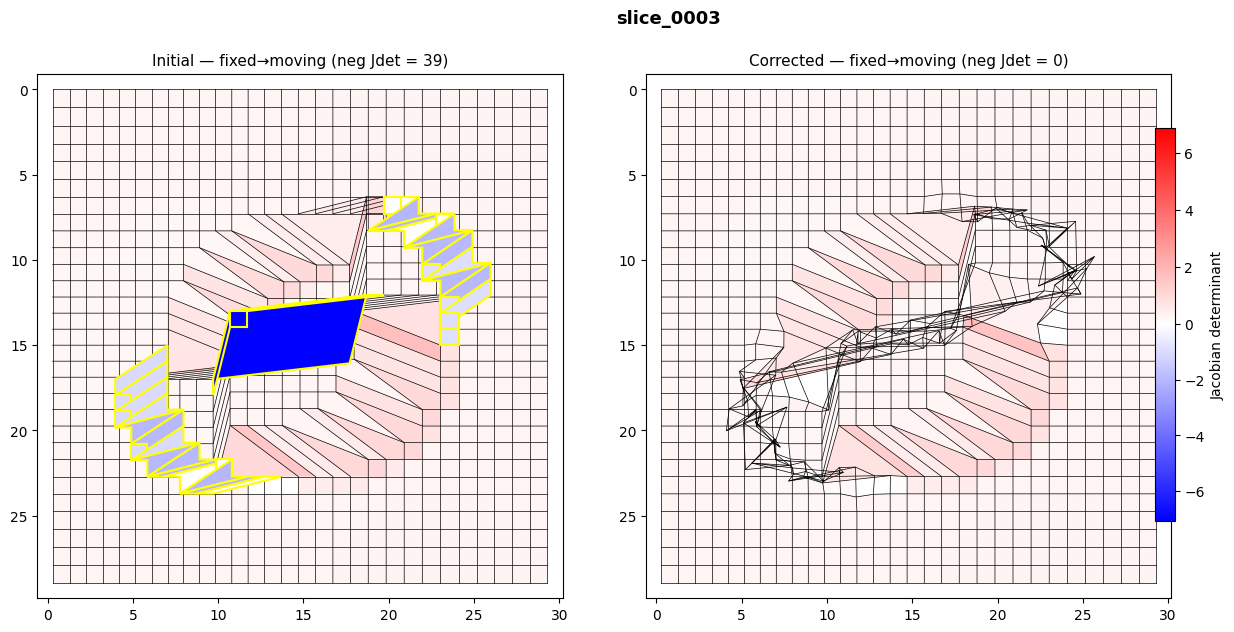

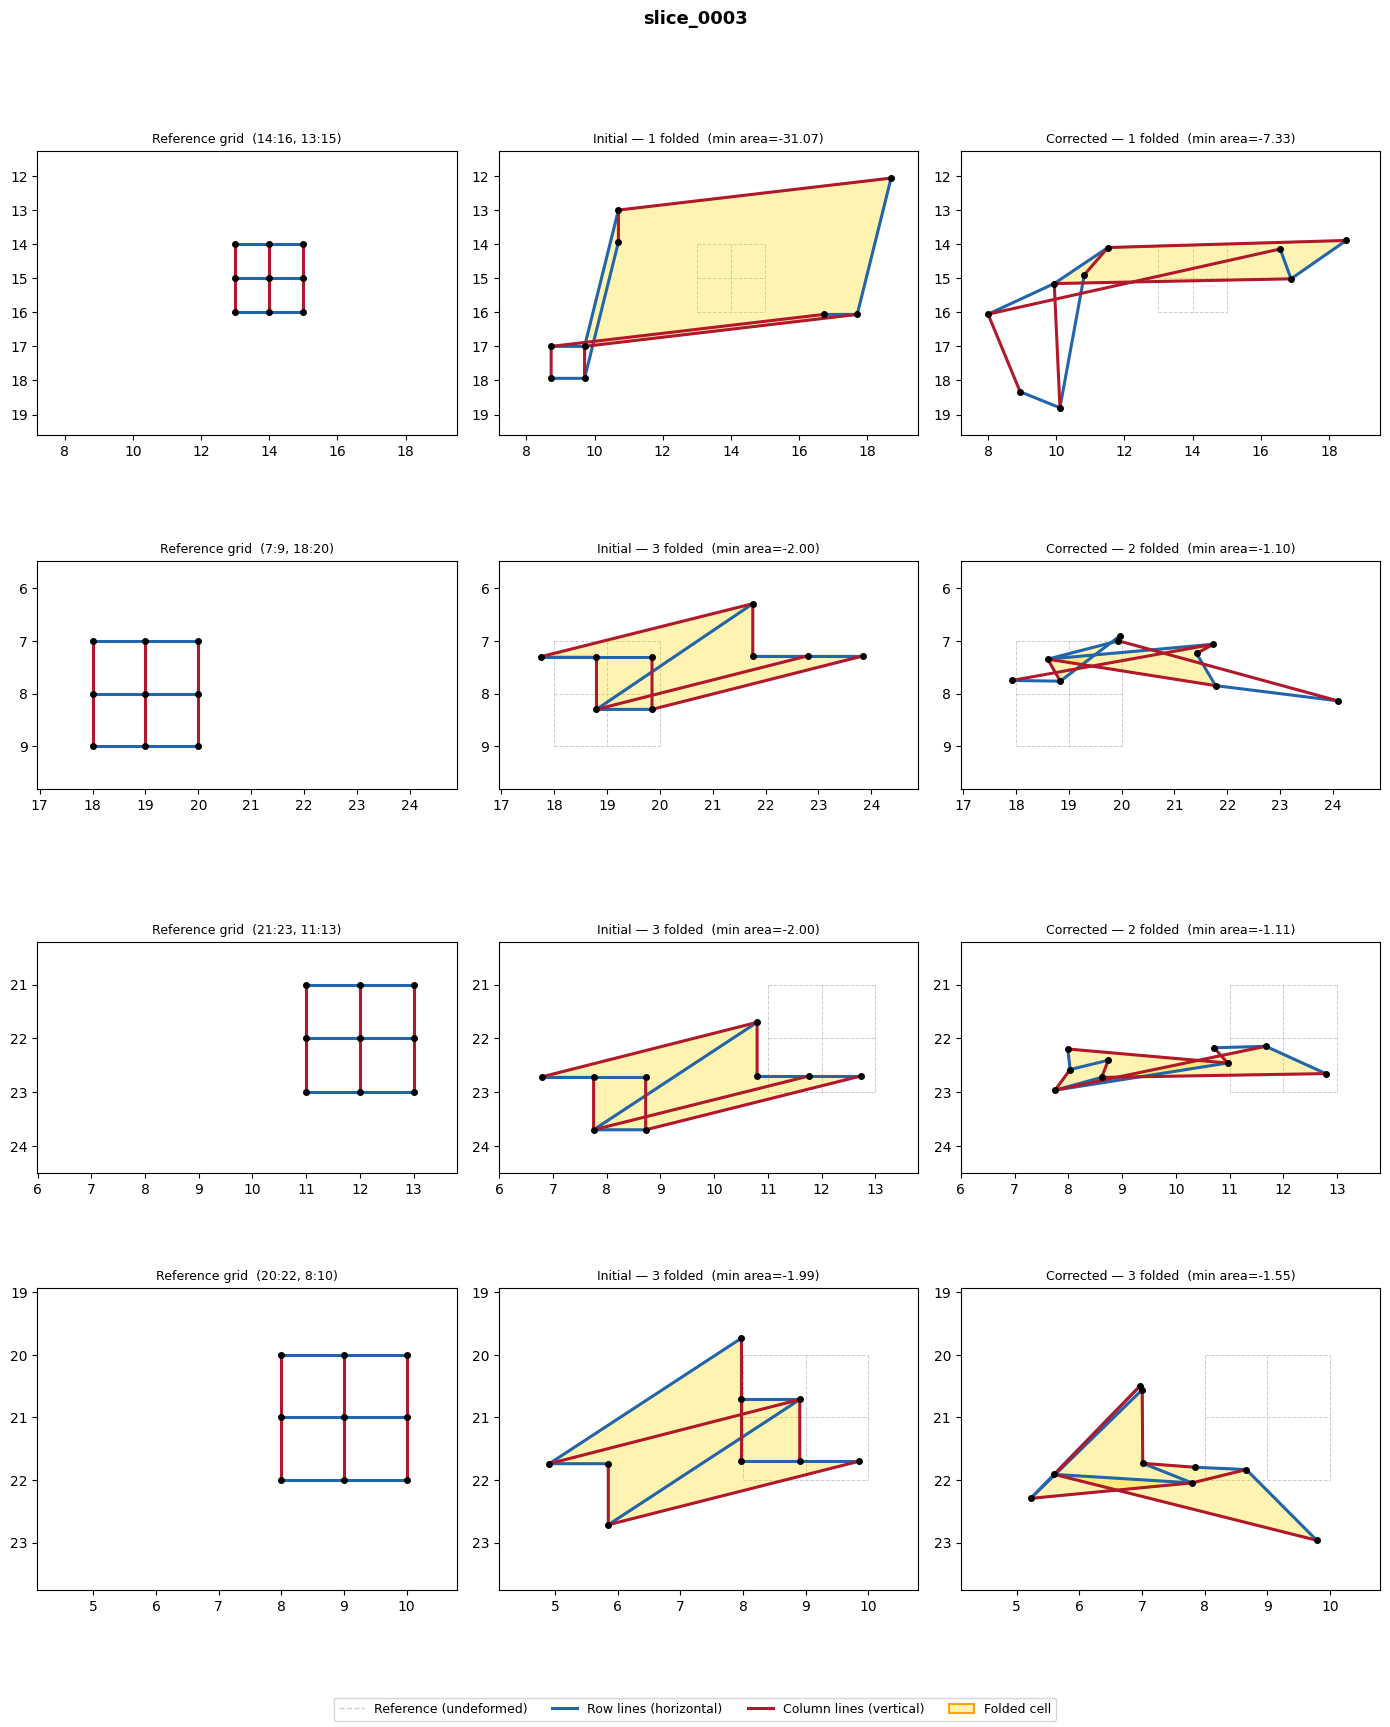

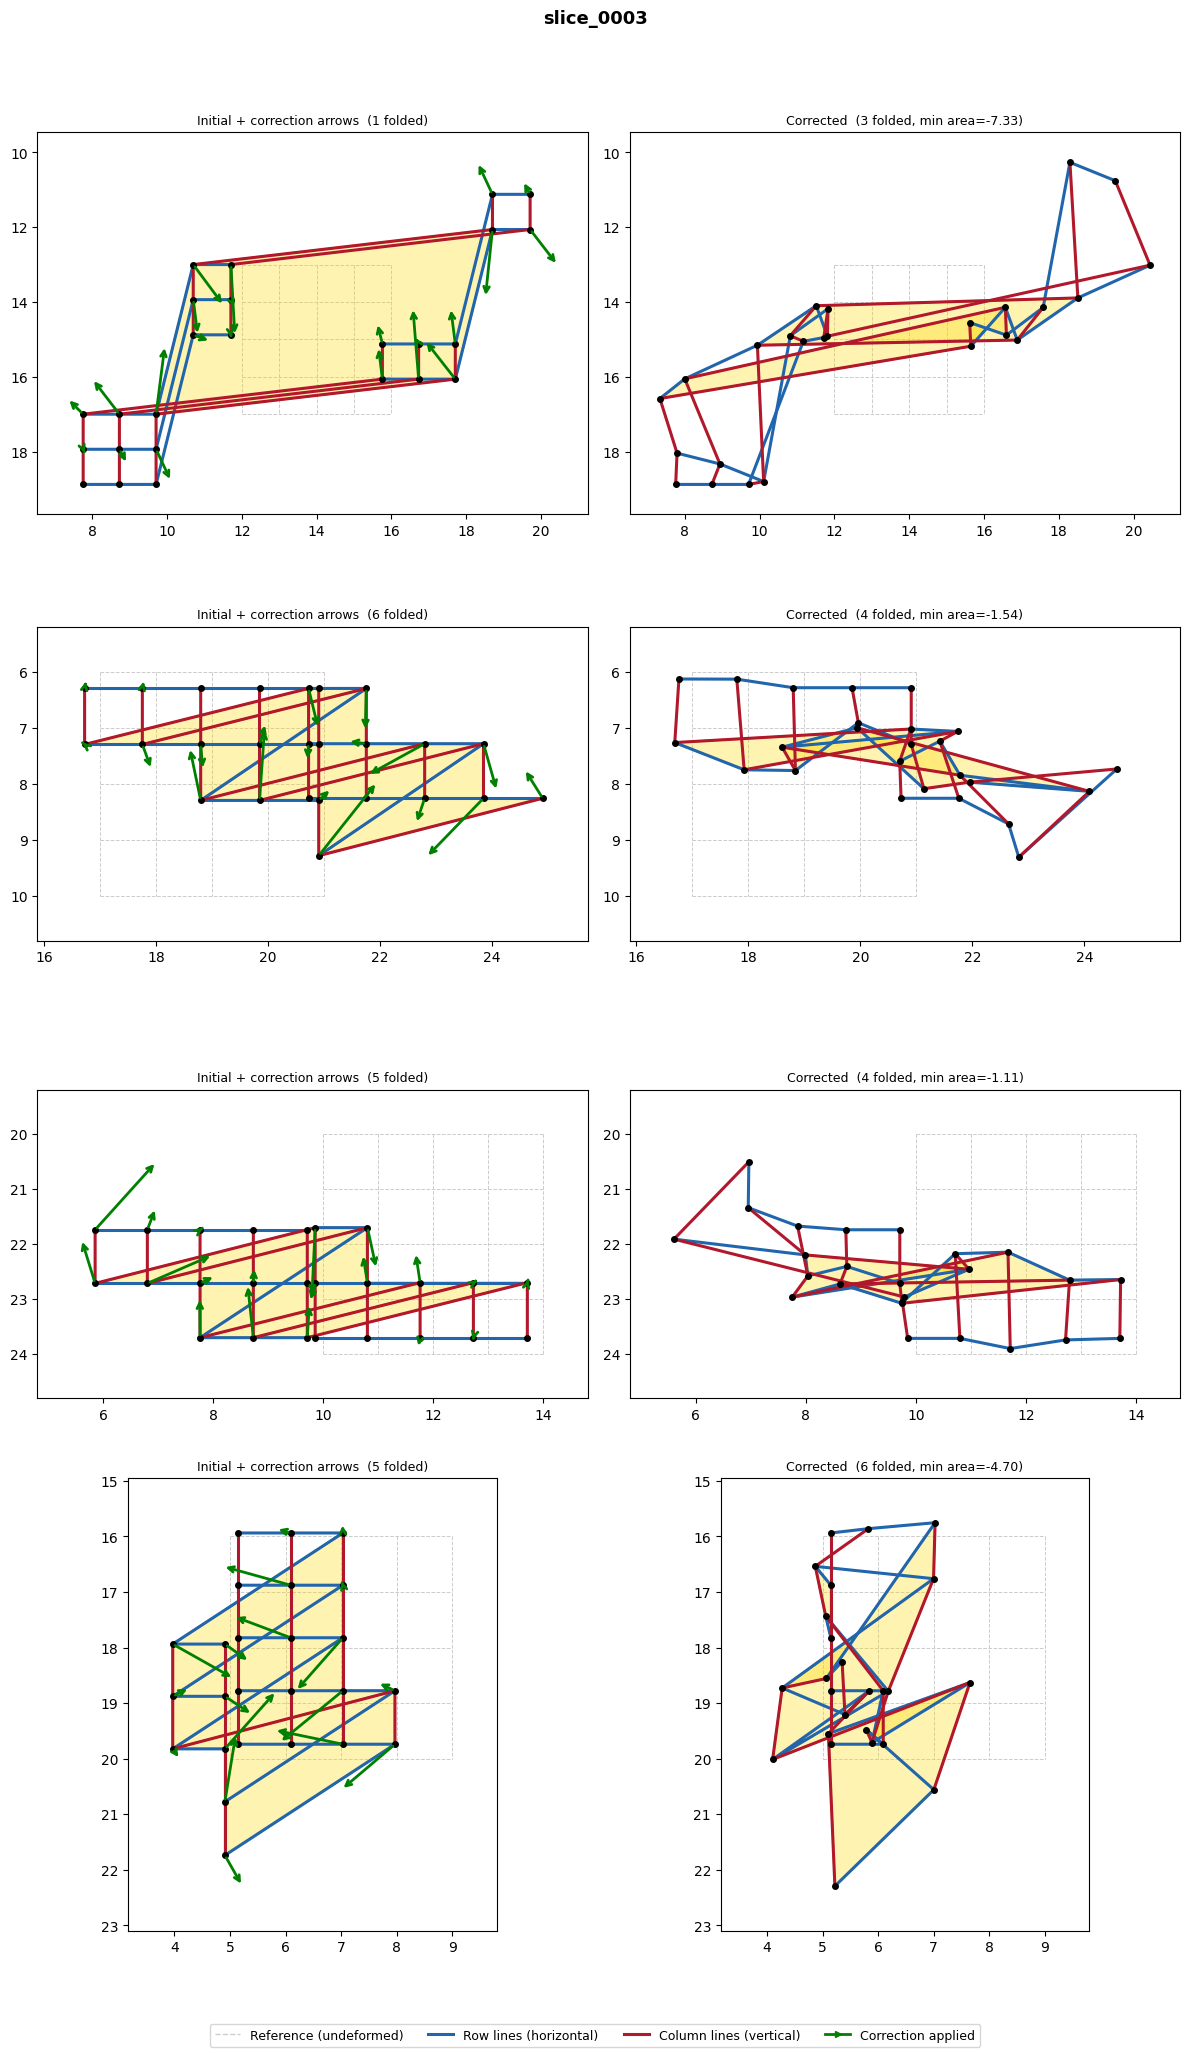


Corrected 1 / 1 slices


In [8]:
corrected_slices = {}  # slice_idx → corrected phi (2, H, W)

for z in slices_to_correct:
    key = f"slice_{z:04d}"
    deformation = extract_slice(warp_zyx, z, scale_factor=SCALE_FACTOR)
    phi = correct_and_show(key, deformation)
    if phi is not None:
        corrected_slices[z] = phi

print(f"\nCorrected {len(corrected_slices)} / {len(slices_to_correct)} slices")

## (Optional) Write corrected slices back into the 3D warp and save

Replace the corrected `[dy, dx]` channels in each slice of the original
warp and write out a new NIfTI file.  Only runs if there are corrected
slices and `SCALE_FACTOR == 1.0` (no downscaling).

In [9]:
if not corrected_slices:
    print("No slices were corrected — nothing to save.")
elif USE_SYNTHETIC:
    # Save corrected warp_zyx as .npy
    warp_out = warp_zyx.copy()
    for z, phi in corrected_slices.items():
        warp_out[1, :, :, z] = phi[0]  # dy
        warp_out[2, :, :, z] = phi[1]  # dx
    out_path = os.path.join(OUTPUT_DIR, "warp_corrected.npy")
    np.save(out_path, warp_out)
    print(f"Saved corrected warp to: {out_path}")
    print(f"  Slices modified: {sorted(corrected_slices.keys())}")
elif SCALE_FACTOR == 1.0:
    import nibabel as nib
    warp_corrected = warp_data.copy()  # (X, Y, Z, 3) in ITK xyz order
    for z, phi in corrected_slices.items():
        warp_corrected[:, :, z, 0] = phi[1]  # dx → ITK x
        warp_corrected[:, :, z, 1] = phi[0]  # dy → ITK y
    out_path = os.path.join(OUTPUT_DIR, "warp_corrected.nii.gz")
    corrected_nii = nib.Nifti1Image(warp_corrected, nii.affine, nii.header)
    nib.save(corrected_nii, out_path)
    print(f"Saved corrected NIfTI to: {out_path}")
    print(f"  Slices modified: {sorted(corrected_slices.keys())}")
else:
    print(f"Skipping NIfTI save: scale_factor={SCALE_FACTOR} (only saves at full resolution)")

Saved corrected warp to: output/ants_corrections\warp_corrected.npy
  Slices modified: [3]


## Summary

In [10]:
print(f"{'Slice':>8s}  {'Size':>10s}  {'Neg init':>10s}  {'Neg final':>10s}  {'Min Jdet':>10s}")
print("-" * 55)

for z in sorted(corrected_slices.keys()):
    phi = corrected_slices[z]
    H, W = phi.shape[-2:]
    jac = jacobian_det2D(phi)
    n_neg = int((jac <= 0).sum())
    min_j = float(jac.min())

    # Initial stats from the original warp
    dy_orig = warp_zyx[1, :, :, z]
    dx_orig = warp_zyx[2, :, :, z]
    jac_orig = jacobian_det2D(np.stack([dy_orig, dx_orig]))
    n_neg_orig = int((jac_orig <= 0).sum())

    print(f"{z:>8d}  {H:>4d}x{W:<4d}  {n_neg_orig:>10d}  {n_neg:>10d}  {min_j:>10.4f}")

   Slice        Size    Neg init   Neg final    Min Jdet
-------------------------------------------------------
       3    30x30            39           0      0.0100
